In [116]:
import rasterio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
import os

pd.options.display.max_columns=200

In [93]:
with rasterio.open("../data/train_dataset_82ddf14911a54c729380209510ae25ac/train_composite/sentinel_2_01000_hokkaido_2019-Q3.tif") as src:
    data=src.read()
    description=src.descriptions
    profile=src.profile
print(data.shape)
print(description)
print(profile)

(12, 1024, 1024)
('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12')
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 1024, 'height': 1024, 'count': 12, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.006328705533892864, 0.0, 139.33355732975213,
       0.0, -0.004069957394033055, 45.52276643291118), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}


In [94]:
with rasterio.open("../data/train_dataset_82ddf14911a54c729380209510ae25ac/train_composite/viirs_09000_tochigi_2024-Q4.tif") as src:
    data=src.read()
    description=src.descriptions
print(data.shape)
print(description)

(1, 1024, 1024)
('avg_rad',)


1 0.94
2 0.98
3 0.92
4 1.09
5 1.06
6 0.99
7 1.0
8 1.13
9 0.97
10 1.03
11 1.09
12 1.11


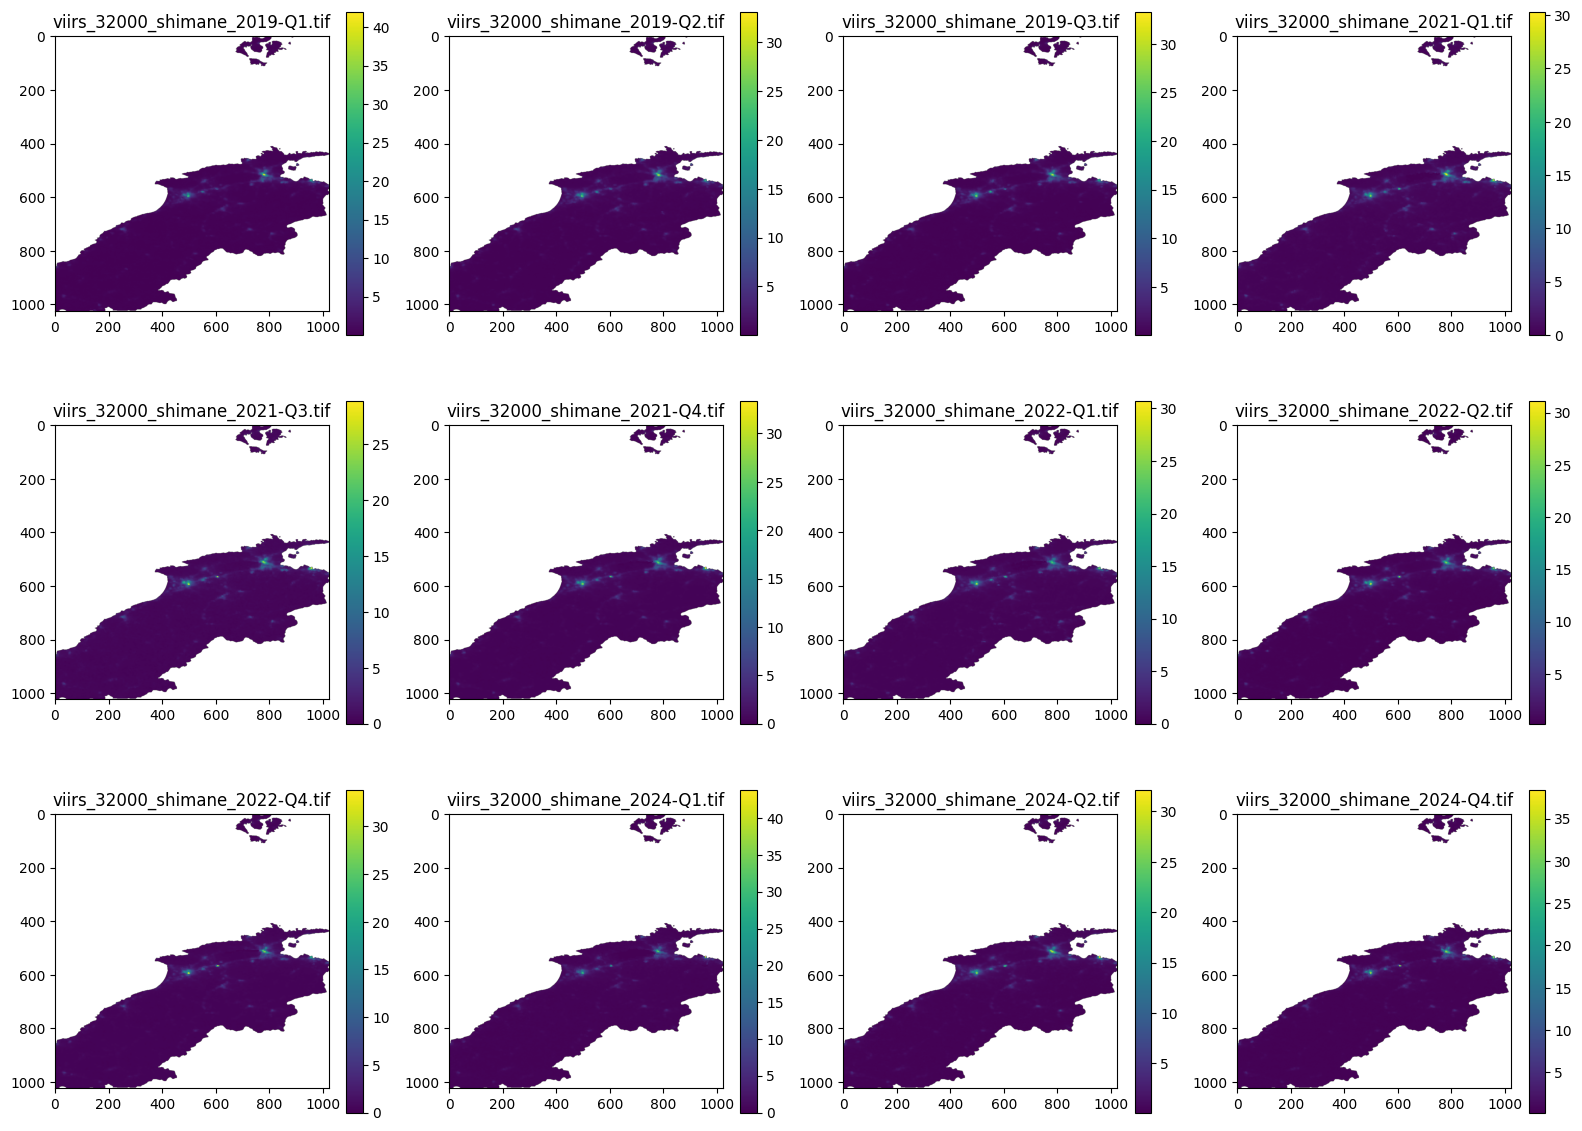

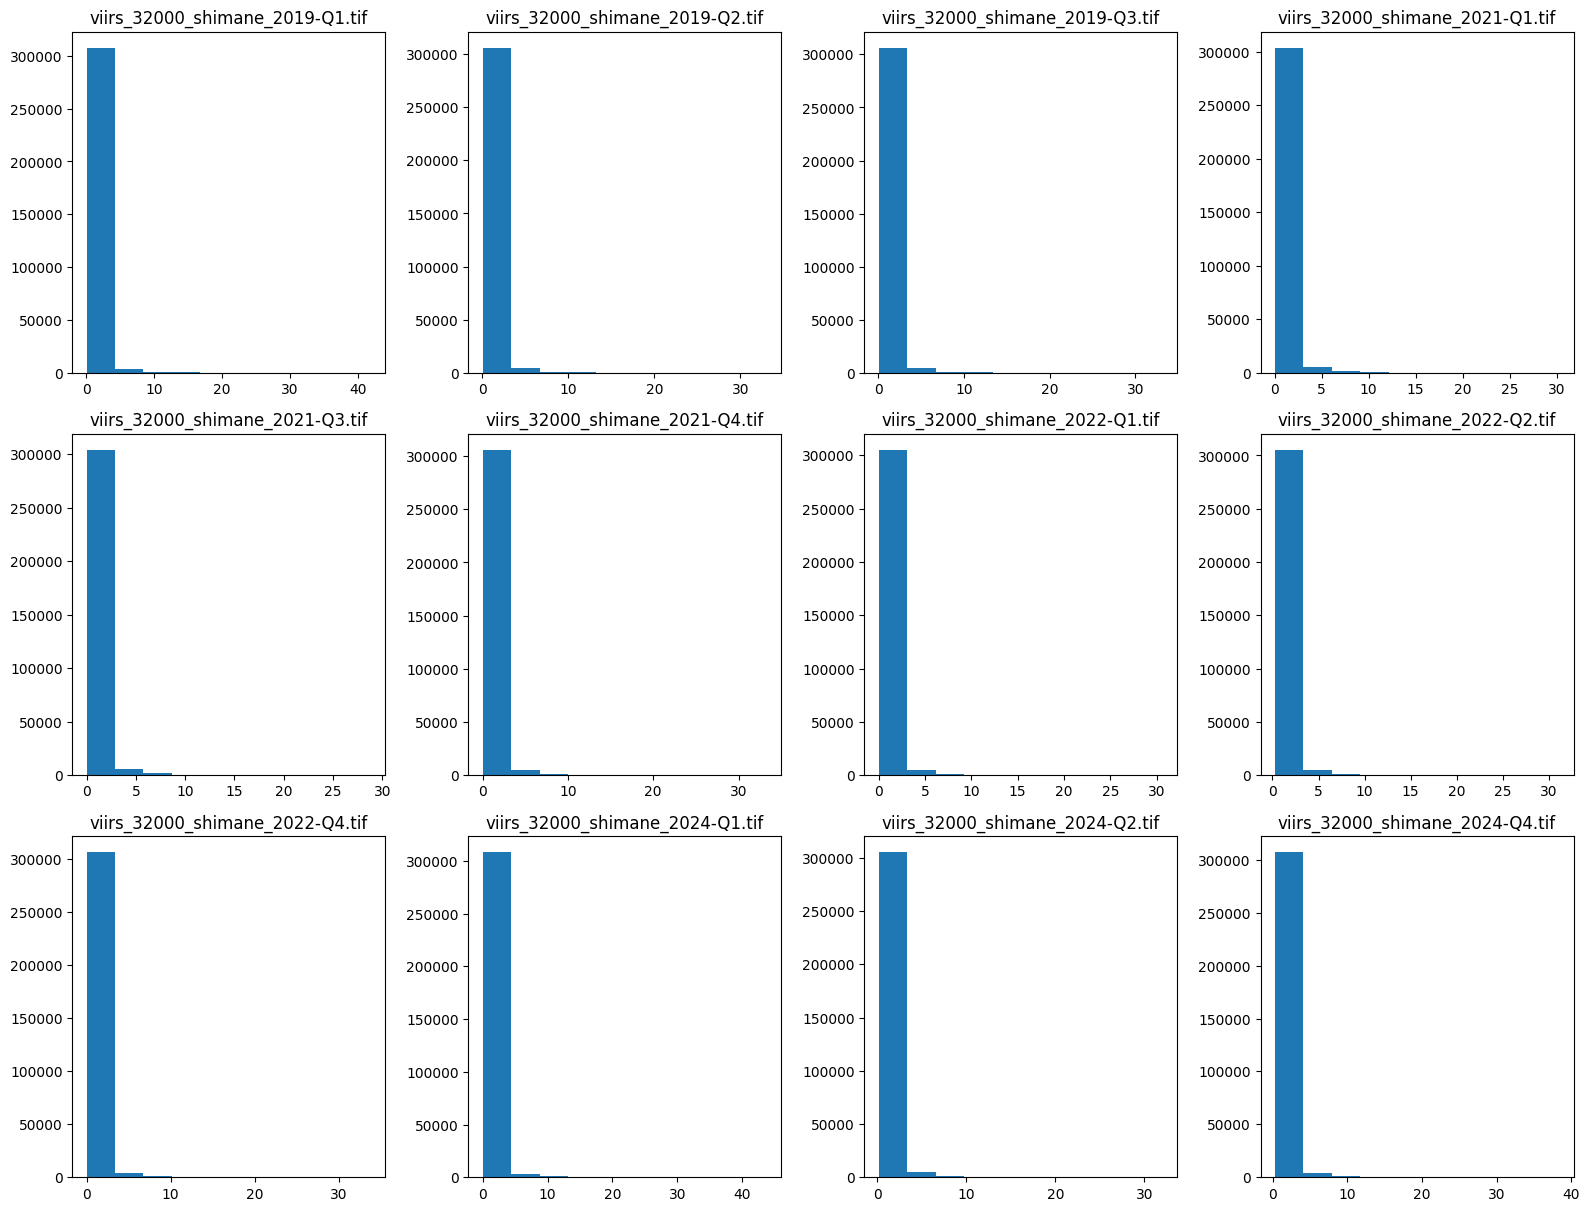

In [121]:
files=glob("../data/train_dataset_82ddf14911a54c729380209510ae25ac/train_composite/viirs_*_shimane_*.tif")
files.sort()
plt.figure(figsize=(16,16))
for i,file in enumerate(files,1):
    with rasterio.open(file) as src:
        data=src.read()
        description=src.descriptions
    # print(data.shape)
    # print(description)
    plt.subplot(4,4,i)
    plt.imshow(data[0])
    plt.colorbar(shrink=0.8)
    plt.title(os.path.basename(file))
    plt.tight_layout()

plt.figure(figsize=(16,16))
for i,file in enumerate(files,1):
    with rasterio.open(file) as src:
        data=src.read()
        description=src.descriptions
    # print(data.shape)
    # print(description)
    plt.subplot(4,4,i)
    plt.hist(data[0].flatten())
    print(i,np.nanpercentile(data[0].flatten(),90))
    plt.title(os.path.basename(file))
    plt.tight_layout()

1 1.86
2 1.76
3 1.82
4 1.75
5 1.69
6 1.95
7 2.13
8 1.82


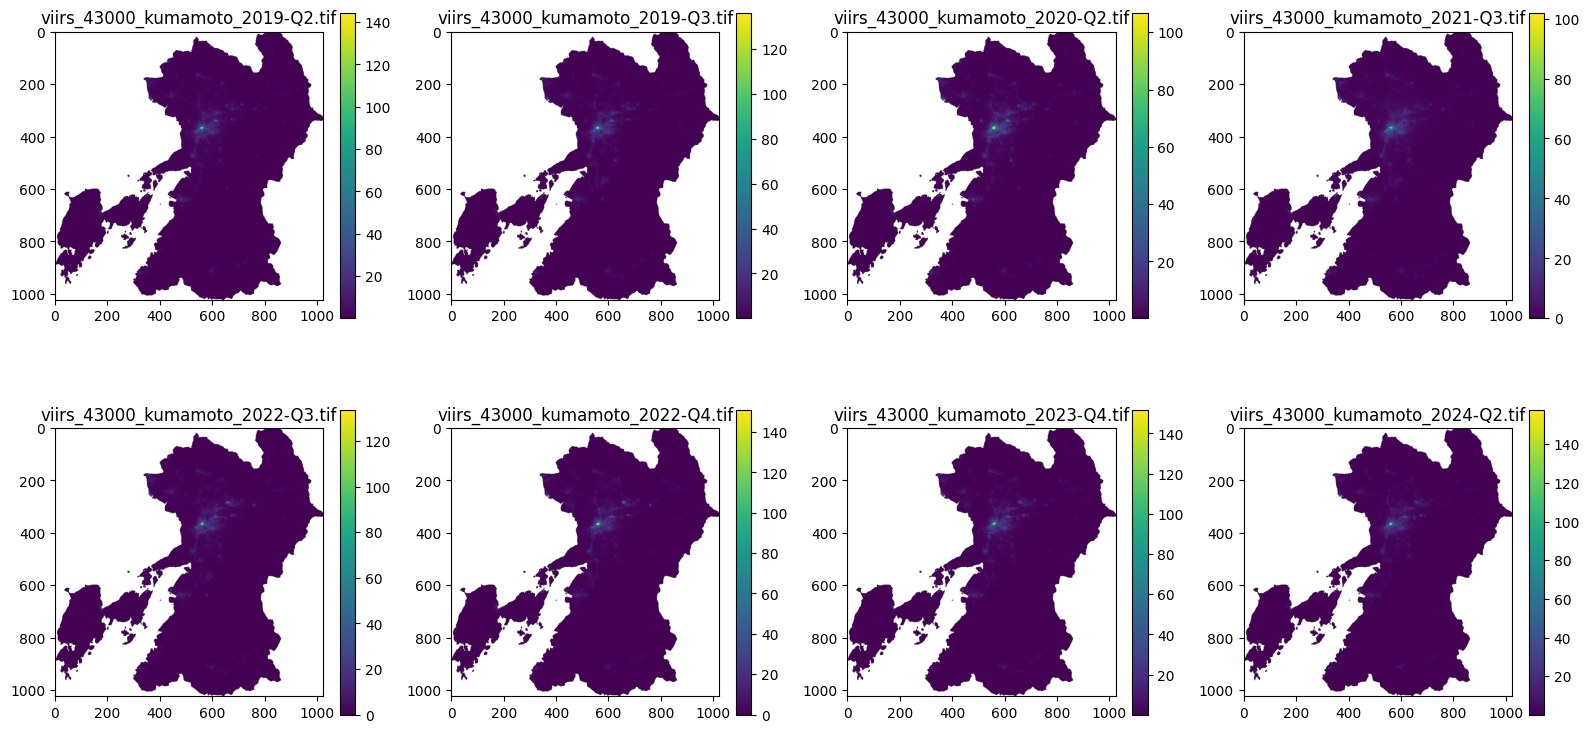

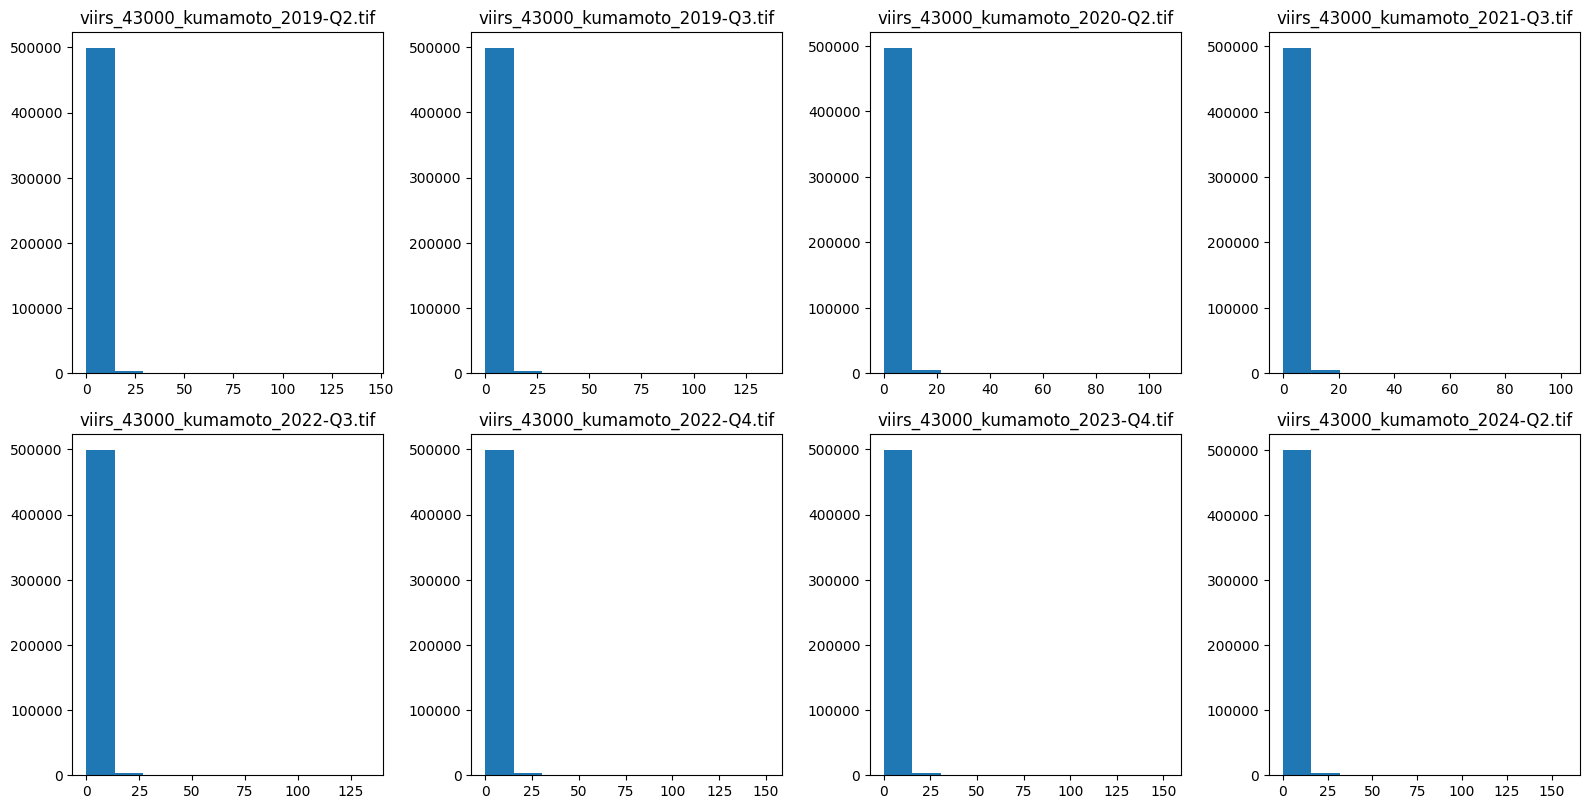

In [122]:
files=glob("../data/train_dataset_82ddf14911a54c729380209510ae25ac/train_composite/viirs_*_kumamoto_*.tif")
files.sort()
plt.figure(figsize=(16,16))
for i,file in enumerate(files,1):
    with rasterio.open(file) as src:
        data=src.read()
        description=src.descriptions
    # print(data.shape)
    # print(description)
    plt.subplot(4,4,i)
    plt.imshow(data[0])
    plt.colorbar(shrink=0.8)
    plt.title(os.path.basename(file))
    plt.tight_layout()

plt.figure(figsize=(16,16))
for i,file in enumerate(files,1):
    with rasterio.open(file) as src:
        data=src.read()
        description=src.descriptions
    # print(data.shape)
    # print(description)
    plt.subplot(4,4,i)
    plt.hist(data[0].flatten())
    print(i,np.nanpercentile(data[0].flatten(),90))
    plt.title(os.path.basename(file))
    plt.tight_layout()

ValueError: num must be an integer with 1 <= num <= 16, not 17

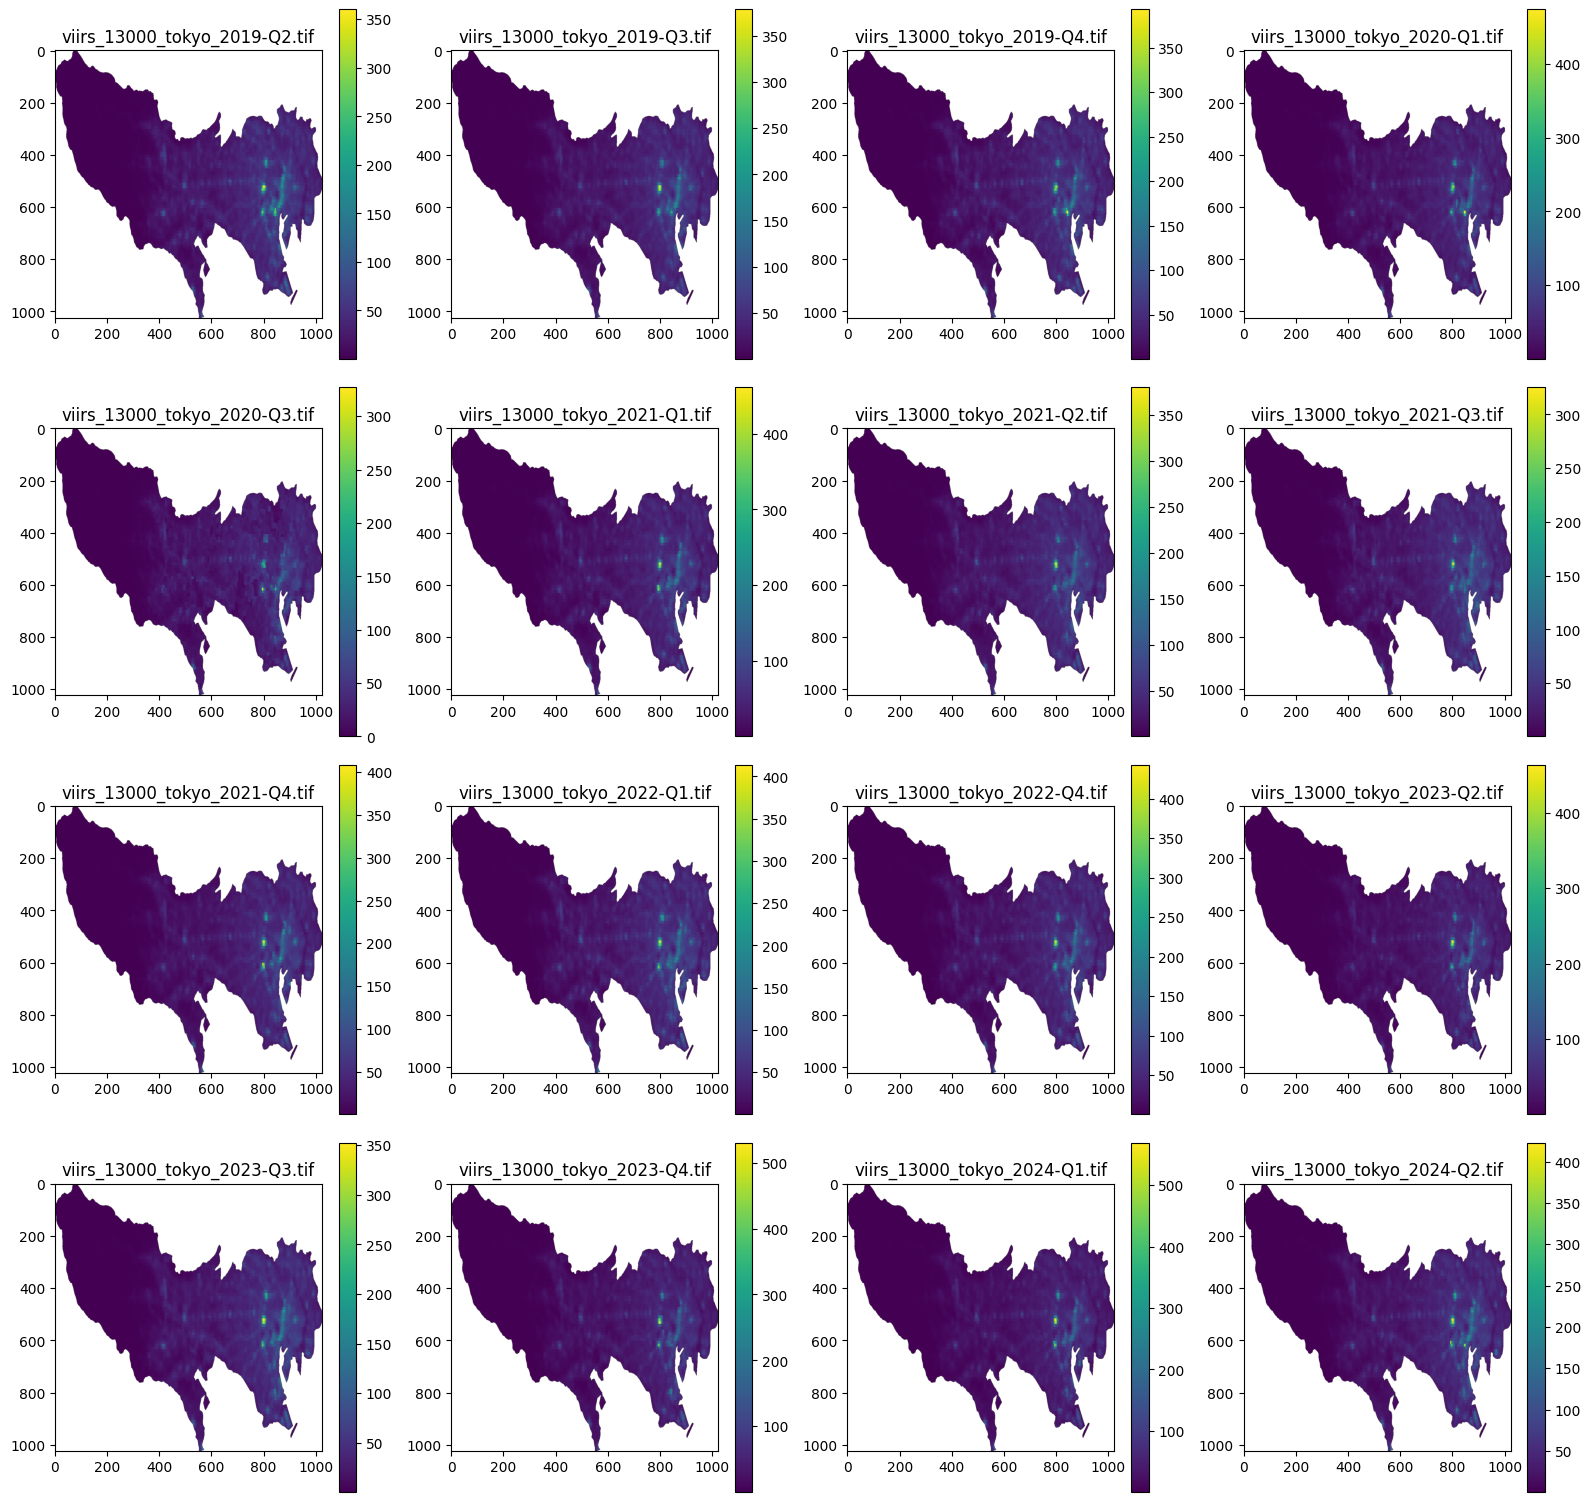

In [123]:
files=glob("../data/train_dataset_82ddf14911a54c729380209510ae25ac/train_composite/viirs_*_tokyo_*.tif")
files.sort()
plt.figure(figsize=(16,16))
for i,file in enumerate(files,1):
    with rasterio.open(file) as src:
        data=src.read()
        description=src.descriptions
    # print(data.shape)
    # print(description)
    plt.subplot(4,4,i)
    plt.imshow(data[0])
    plt.colorbar(shrink=0.8)
    plt.title(os.path.basename(file))
    plt.tight_layout()

plt.figure(figsize=(16,16))
for i,file in enumerate(files,1):
    with rasterio.open(file) as src:
        data=src.read()
        description=src.descriptions
    # print(data.shape)
    # print(description)
    plt.subplot(4,4,i)
    plt.hist(data[0].flatten())
    print(i,np.nanpercentile(data[0].flatten(),90))
    plt.title(os.path.basename(file))
    plt.tight_layout()

1.82


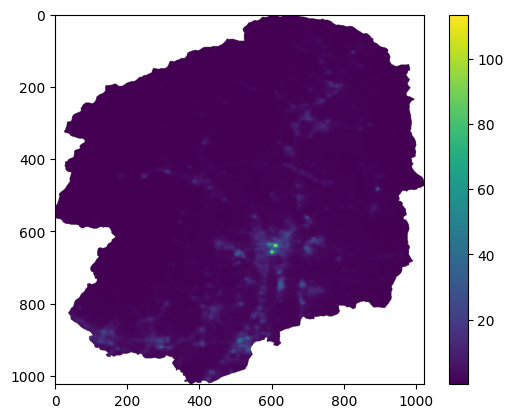

In [5]:
df=pd.read_csv("../data/train_dataset_82ddf14911a54c729380209510ae25ac/train_tabular.csv")

<Axes: >

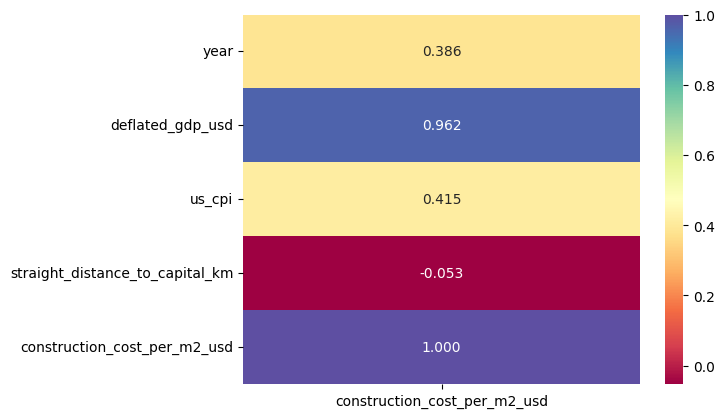

In [29]:
df_number=df.select_dtypes("number")
df_corr=df_number.corr()
df_corr=df_corr[["construction_cost_per_m2_usd"]]
sns.heatmap(df_corr,cmap="Spectral",annot=True,fmt=".3f")

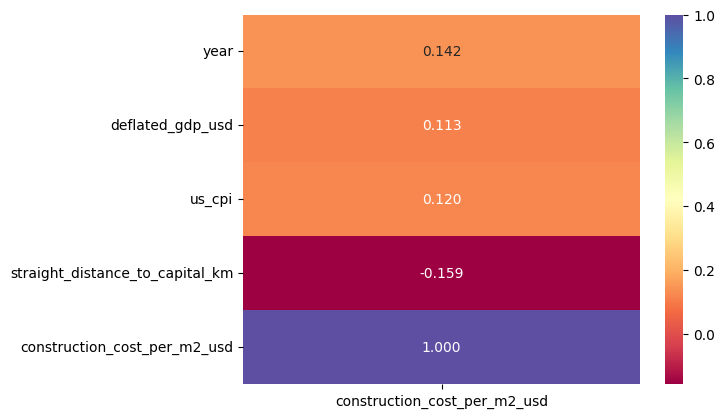

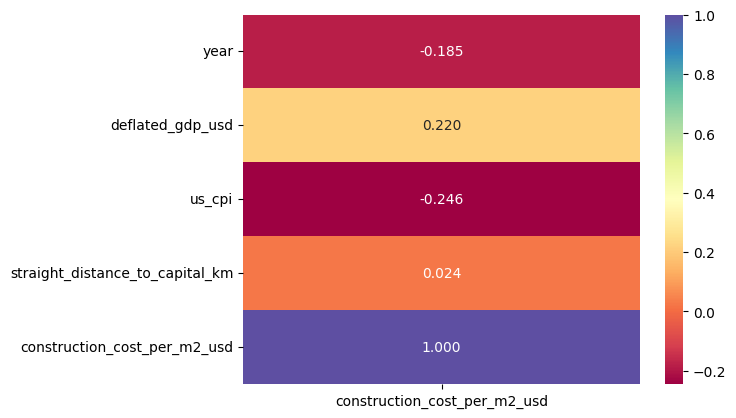

In [33]:
df_plot=df.copy()
for country in df["country"].unique():
    df_country=df_plot[df_plot["country"]==country]
    df_number=df_country.select_dtypes("number")
    df_corr=df_number.corr()
    df_corr=df_corr[["construction_cost_per_m2_usd"]]
    plt.figure()
    sns.heatmap(df_corr,cmap="Spectral",annot=True,fmt=".3f")

<Axes: >

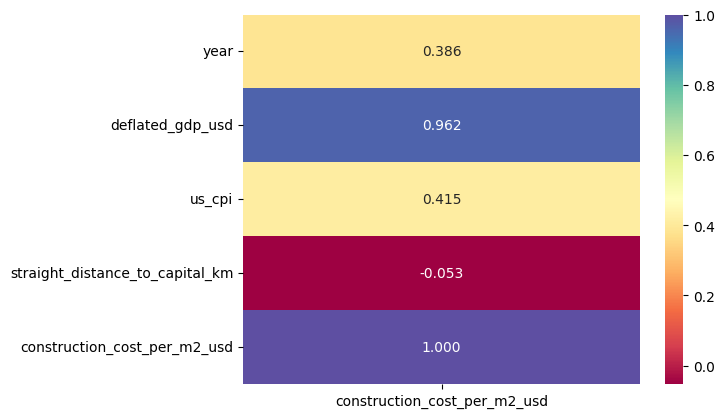

In [ ]:
sns.heatmap(df_corr,cmap="Spectral",annot=True,fmt=".3f")

<Axes: xlabel='deflated_gdp_usd', ylabel='construction_cost_per_m2_usd'>

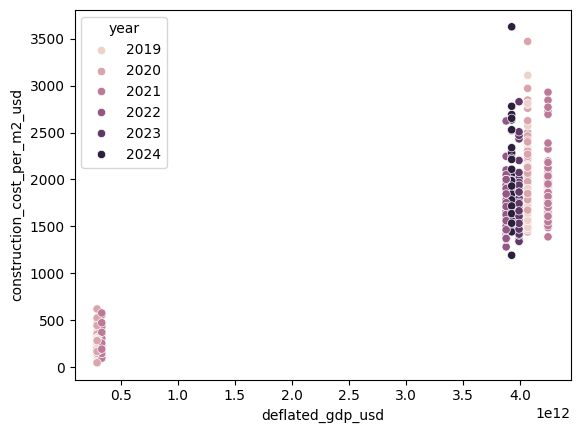

In [36]:
sns.scatterplot(data=df,x="deflated_gdp_usd",y="construction_cost_per_m2_usd",hue="year")

In [34]:
df

,data_id,geolocation_name,quarter_label,country,year,deflated_gdp_usd,us_cpi,developed_country,landlocked,region_economic_classification,access_to_airport,access_to_port,access_to_highway,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,sentinel2_tiff_file_name,viirs_tiff_file_name,construction_cost_per_m2_usd
0,LP81L,Dinagat Islands,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,No,Lower-middle income,No,Yes,Yes,No,770.0,Moderate,Yes,High,Very Low,Af,sentinel_2_dinagat_islands_2019-Q3.tif,viirs_dinagat_islands_2019-Q3.tif,129.997420
1,E7EOB,29000 Nara,2024-Q2,Japan,2024,3.928801e+12,143.968241,Yes,Yes,High income,No,No,Yes,Yes,370.0,Moderate,Yes,Low,Very Low,Cfa,sentinel_2_29000_nara_2024-Q2.tif,viirs_29000_nara_2024-Q2.tif,1567.878774
2,WAOUA,05000 Akita,2020-Q1,Japan,2020,4.069008e+12,118.435291,Yes,No,High income,Yes,Yes,Yes,Yes,450.0,Moderate,Yes,Low,Very Low,Dfa,sentinel_2_05000_akita_2020-Q1.tif,viirs_05000_akita_2020-Q1.tif,2009.827701
3,2IZ5P,Cotabato,2020-Q4,Philippines,2020,2.912443e+11,119.402476,No,Yes,Lower-middle income,Yes,No,Yes,No,870.0,High,Yes,Moderate,Very Low,Af,sentinel_2_cotabato_2020-Q4.tif,viirs_cotabato_2020-Q4.tif,377.279961
4,RJ5XF,Pampanga,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,Yes,Lower-middle income,Yes,No,Yes,Yes,65.0,Moderate,Yes,Moderate,Very Low,Am,sentinel_2_pampanga_2019-Q3.tif,viirs_pampanga_2019-Q3.tif,163.905688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,SPD2S,Quirino,2021-Q3,Philippines,2021,3.321833e+11,125.484873,No,Yes,Lower-middle income,No,No,Yes,No,265.0,Moderate,Yes,Moderate,Very Low,Am,sentinel_2_quirino_2021-Q3.tif,viirs_quirino_2021-Q3.tif,254.972580
1020,45ED5,Bulacan,2021-Q4,Philippines,2021,3.321833e+11,127.389434,No,No,Lower-middle income,No,No,Yes,Yes,30.0,Moderate,Yes,High,Very Low,Am,sentinel_2_bulacan_2021-Q4.tif,viirs_bulacan_2021-Q4.tif,190.829313
1021,H2VFF,24000 Mie,2020-Q3,Japan,2020,4.069008e+12,119.128540,Yes,No,High income,No,Yes,Yes,Yes,320.0,High,Yes,Moderate,Low,Cfa,sentinel_2_24000_mie_2020-Q3.tif,viirs_24000_mie_2020-Q3.tif,1850.491892
1022,WX7PT,06000 Yamagata,2023-Q4,Japan,2023,3.993447e+12,140.861386,Yes,Yes,High income,Yes,No,Yes,Yes,300.0,Moderate,Yes,Low,Very Low,Dfa,sentinel_2_06000_yamagata_2023-Q4.tif,viirs_06000_yamagata_2023-Q4.tif,1665.935980


In [55]:
df_res=pd.read_csv("../data/result/case002/oof_predictions.csv")
# df_res=pd.read_csv("../data/result/initial_tabular_only/oof_predictions.csv")
df_res

,data_id,geolocation_name,quarter_label,country,year,deflated_gdp_usd,us_cpi,developed_country,landlocked,region_economic_classification,access_to_airport,access_to_port,access_to_highway,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,sentinel2_tiff_file_name,viirs_tiff_file_name,construction_cost_per_m2_usd,B1_pct0,B1_pct10,B1_pct20,B1_pct30,B1_pct40,B1_pct50,B1_pct60,B1_pct70,B1_pct80,B1_pct90,B1_pct100,B1_mean,B1_std,B2_pct0,B2_pct10,B2_pct20,B2_pct30,B2_pct40,B2_pct50,B2_pct60,B2_pct70,B2_pct80,B2_pct90,B2_pct100,B2_mean,B2_std,B3_pct0,B3_pct10,B3_pct20,B3_pct30,B3_pct40,B3_pct50,B3_pct60,B3_pct70,B3_pct80,B3_pct90,B3_pct100,B3_mean,B3_std,B4_pct0,B4_pct10,B4_pct20,B4_pct30,B4_pct40,B4_pct50,B4_pct60,B4_pct70,B4_pct80,B4_pct90,B4_pct100,B4_mean,B4_std,B5_pct0,B5_pct10,B5_pct20,B5_pct30,B5_pct40,B5_pct50,B5_pct60,B5_pct70,B5_pct80,B5_pct90,B5_pct100,B5_mean,B5_std,B6_pct0,B6_pct10,B6_pct20,B6_pct30,B6_pct40,B6_pct50,B6_pct60,B6_pct70,B6_pct80,B6_pct90,B6_pct100,B6_mean,...,BSI_pct70,BSI_pct80,BSI_pct90,BSI_pct100,BSI_mean,BSI_std,NBSI_pct0,NBSI_pct10,NBSI_pct20,NBSI_pct30,NBSI_pct40,NBSI_pct50,NBSI_pct60,NBSI_pct70,NBSI_pct80,NBSI_pct90,NBSI_pct100,NBSI_mean,NBSI_std,NDWI_pct0,NDWI_pct10,NDWI_pct20,NDWI_pct30,NDWI_pct40,NDWI_pct50,NDWI_pct60,NDWI_pct70,NDWI_pct80,NDWI_pct90,NDWI_pct100,NDWI_mean,NDWI_std,MNDWI_pct0,MNDWI_pct10,MNDWI_pct20,MNDWI_pct30,MNDWI_pct40,MNDWI_pct50,MNDWI_pct60,MNDWI_pct70,MNDWI_pct80,MNDWI_pct90,MNDWI_pct100,MNDWI_mean,MNDWI_std,Clay_pct0,Clay_pct10,Clay_pct20,Clay_pct30,Clay_pct40,Clay_pct50,Clay_pct60,Clay_pct70,Clay_pct80,Clay_pct90,Clay_pct100,Clay_mean,Clay_std,IronOxide_pct0,IronOxide_pct10,IronOxide_pct20,IronOxide_pct30,IronOxide_pct40,IronOxide_pct50,IronOxide_pct60,IronOxide_pct70,IronOxide_pct80,IronOxide_pct90,IronOxide_pct100,IronOxide_mean,IronOxide_std,Carbonate_pct0,Carbonate_pct10,Carbonate_pct20,Carbonate_pct30,Carbonate_pct40,Carbonate_pct50,Carbonate_pct60,Carbonate_pct70,Carbonate_pct80,Carbonate_pct90,Carbonate_pct100,Carbonate_mean,Carbonate_std,avg_rad_pct0,avg_rad_pct10,avg_rad_pct20,avg_rad_pct30,avg_rad_pct40,avg_rad_pct50,avg_rad_pct60,avg_rad_pct70,avg_rad_pct80,avg_rad_pct90,avg_rad_pct100,avg_rad_mean,avg_rad_std,oof_lgb,oof_cb,oof_ensemble
0,LP81L,Dinagat Islands,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,No,Lower-middle income,No,Yes,Yes,No,770.0,Moderate,Yes,High,Very Low,Af,sentinel_2_dinagat_islands_2019-Q3.tif,viirs_dinagat_islands_2019-Q3.tif,129.997420,79.0,235.0,282.0,318.0,360.0,411.0,491.0,676.0,1505.0,4305.9,12442.0,1306.214859,2083.542109,109.0,283.0,318.0,354.0,396.0,448.0,526.0,702.0,1390.0,4237.0,12850.0,1304.793386,2028.163855,112.0,492.0,544.0,595.0,653.0,724.0,814.0,973.0,1501.0,4131.0,12429.0,1476.873568,1876.246837,55.0,236.0,272.0,319.0,380.0,463.0,568.0,775.0,1406.0,3918.0,12107.0,1239.978003,1876.147938,66.0,799.0,881.0,956.0,1042.0,1147.0,1267.0,1438.0,1853.0,4381.0,12849.0,1836.360197,1858.186597,45.0,2110.0,2415.0,2593.0,2738.0,2872.0,3015.0,3193.0,3482.0,4747.0,12033.0,3184.346665,...,-0.138990,-0.096317,-0.051140,0.397685,-0.240089,0.152624,-0.696751,-0.452918,-0.427833,-0.402794,-0.366435,-0.313729,-0.255161,-0.200000,-0.147581,-0.084259,0.439789,-0.286398,0.153233,-0.850387,-0.750380,-0.726949,-0.701971,-0.670951,-0.633071,-0.586303,-0.486990,-0.261191,-0.037702,0.832858,-0.518670,0.267313,-0.738832,-0.507313,-0.477261,-0.452655,-0.428246,-0.401658,-0.367091,-0.283019,-0.096182,0.100802,0.863447,-0.303787,0.235211,0.607184,1.239295,1.393008,1.631015,1.863482,2.048593,2.204152,2.343933,2.459103,2.569671,3.558559,1.967181,0.498286,0.106383,0.747967,0.805690,0.853448,0.894484,0.928119,0.963603,1.018124,1.111111,1.268349,3.570909,0.981737,0.258615,0.169127,0.345718,0.368197,0.391037,0.426642,0.482034,0.549976,0.622843,0.696757,0.787294,2.256161,0.537562,0.201261,-0.04,0.11,0.13,0.15,0.16,0.17,0.18,0.20,0.22,0.27,7.700000,0.2091

/tmp/ipykernel_21026/1403331866.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_res,x="construction_cost_per_m2_usd",y="oof_ensemble",palette="Spectral")


<Axes: xlabel='construction_cost_per_m2_usd', ylabel='oof_ensemble'>

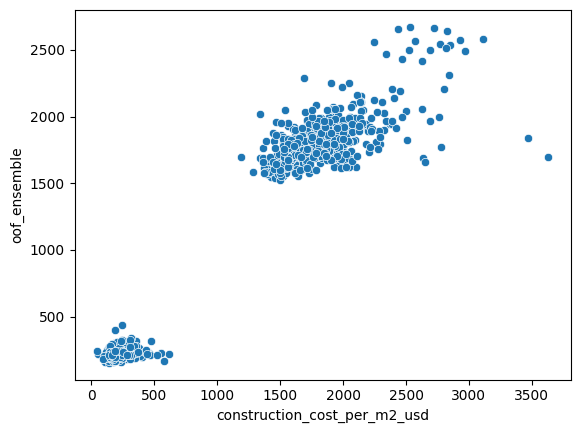

In [56]:
plt.figure()
sns.scatterplot(data=df_res,x="construction_cost_per_m2_usd",y="oof_ensemble",palette="Spectral")
# plt.figure()
# sns.scatterplot(data=df_res,x="construction_cost_per_m2_usd",y="oof_ensemble",hue="NDBI_pct50",palette="Spectral")
# plt.figure()
# sns.scatterplot(data=df_res,x="construction_cost_per_m2_usd",y="oof_ensemble",hue="avg_rad_pct50",palette="Spectral")

In [57]:
df_res["diff"]=df_res["oof_ensemble"]-df_res["construction_cost_per_m2_usd"]
df_res["diff_abs"]=df_res["diff"].abs()
df_res.sort_values("diff_abs",ascending=False,inplace=True)

/tmp/ipykernel_21026/1597325419.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_res["diff"]=df_res["oof_ensemble"]-df_res["construction_cost_per_m2_usd"]
/tmp/ipykernel_21026/1597325419.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_res["diff_abs"]=df_res["diff"].abs()


In [58]:
df_res

,data_id,geolocation_name,quarter_label,country,year,deflated_gdp_usd,us_cpi,developed_country,landlocked,region_economic_classification,access_to_airport,access_to_port,access_to_highway,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,sentinel2_tiff_file_name,viirs_tiff_file_name,construction_cost_per_m2_usd,B1_pct0,B1_pct10,B1_pct20,B1_pct30,B1_pct40,B1_pct50,B1_pct60,B1_pct70,B1_pct80,B1_pct90,B1_pct100,B1_mean,B1_std,B2_pct0,B2_pct10,B2_pct20,B2_pct30,B2_pct40,B2_pct50,B2_pct60,B2_pct70,B2_pct80,B2_pct90,B2_pct100,B2_mean,B2_std,B3_pct0,B3_pct10,B3_pct20,B3_pct30,B3_pct40,B3_pct50,B3_pct60,B3_pct70,B3_pct80,B3_pct90,B3_pct100,B3_mean,B3_std,B4_pct0,B4_pct10,B4_pct20,B4_pct30,B4_pct40,B4_pct50,B4_pct60,B4_pct70,B4_pct80,B4_pct90,B4_pct100,B4_mean,B4_std,B5_pct0,B5_pct10,B5_pct20,B5_pct30,B5_pct40,B5_pct50,B5_pct60,B5_pct70,B5_pct80,B5_pct90,B5_pct100,B5_mean,B5_std,B6_pct0,B6_pct10,B6_pct20,B6_pct30,B6_pct40,B6_pct50,B6_pct60,B6_pct70,B6_pct80,B6_pct90,B6_pct100,B6_mean,...,BSI_pct90,BSI_pct100,BSI_mean,BSI_std,NBSI_pct0,NBSI_pct10,NBSI_pct20,NBSI_pct30,NBSI_pct40,NBSI_pct50,NBSI_pct60,NBSI_pct70,NBSI_pct80,NBSI_pct90,NBSI_pct100,NBSI_mean,NBSI_std,NDWI_pct0,NDWI_pct10,NDWI_pct20,NDWI_pct30,NDWI_pct40,NDWI_pct50,NDWI_pct60,NDWI_pct70,NDWI_pct80,NDWI_pct90,NDWI_pct100,NDWI_mean,NDWI_std,MNDWI_pct0,MNDWI_pct10,MNDWI_pct20,MNDWI_pct30,MNDWI_pct40,MNDWI_pct50,MNDWI_pct60,MNDWI_pct70,MNDWI_pct80,MNDWI_pct90,MNDWI_pct100,MNDWI_mean,MNDWI_std,Clay_pct0,Clay_pct10,Clay_pct20,Clay_pct30,Clay_pct40,Clay_pct50,Clay_pct60,Clay_pct70,Clay_pct80,Clay_pct90,Clay_pct100,Clay_mean,Clay_std,IronOxide_pct0,IronOxide_pct10,IronOxide_pct20,IronOxide_pct30,IronOxide_pct40,IronOxide_pct50,IronOxide_pct60,IronOxide_pct70,IronOxide_pct80,IronOxide_pct90,IronOxide_pct100,IronOxide_mean,IronOxide_std,Carbonate_pct0,Carbonate_pct10,Carbonate_pct20,Carbonate_pct30,Carbonate_pct40,Carbonate_pct50,Carbonate_pct60,Carbonate_pct70,Carbonate_pct80,Carbonate_pct90,Carbonate_pct100,Carbonate_mean,Carbonate_std,avg_rad_pct0,avg_rad_pct10,avg_rad_pct20,avg_rad_pct30,avg_rad_pct40,avg_rad_pct50,avg_rad_pct60,avg_rad_pct70,avg_rad_pct80,avg_rad_pct90,avg_rad_pct100,avg_rad_mean,avg_rad_std,oof_lgb,oof_cb,oof_ensemble,diff,diff_abs
439,CD0RL,32000 Shimane,2024-Q2,Japan,2024,3.928801e+12,143.968241,Yes,No,High income,Yes,Yes,Yes,Yes,650.0,Moderate,Yes,Moderate,Low,Cfa,sentinel_2_32000_shimane_2024-Q2.tif,viirs_32000_shimane_2024-Q2.tif,3628.201594,115.0,204.5,223.5,240.0,256.0,274.0,296.0,329.5,395.5,519.0,3634.5,325.024823,155.884248,141.0,239.5,261.5,279.5,296.5,315.0,338.0,375.5,458.0,608.0,4867.0,377.016574,185.757265,283.0,471.5,509.0,537.0,563.0,590.0,621.50,661.0,731.0,863.00,4762.0,635.592584,185.871937,148.5,242.5,267.0,289.0,310.0,332.0,362.0,417.5,533.0,801.0,4849.0,430.083226,261.190460,187.0,750.5,832.5,888.50,935.5,981.0,1031.0,1093.0,1180.0,1318.5,5190.0,1011.904203,245.767561,165.0,1930.0,2232.5,2428.5,2589.0,2737.0,2879.0,3027.5,3193.5,3422.00,7009.0,2683.414604,...,-0.077178,0.252510,-0.281642,0.121323,-0.567239,-0.425002,-0.410536,-0.399010,-0.387391,-0.373923,-0.355621,-0.323474,-0.256905,-0.152455,0.319174,-0.329660,0.115926,-0.808506,-0.755634,-0.744840,-0.735831,-0.727242,-0.718170,-0.706733,-0.686718,-0.624970,-0.454177,0.611018,-0.654498,0.175563,-0.639792,-0.515878,-0.501693,-0.490147,-0.479062,-0.467535,-0.454464,-0.437945,-0.412366,-0.347771,0.596515,-0.433924,0.135702,0.797178,1.441259,1.726384,1.892276,1.989267,2.060960,2.121212,2.173603,2.220503,2.272135,2.707746,1.962961,0.321005,0.425481,0.941304,0.978799,1.008475,1.036630,1.067742,1.106294,1.158640,1.234130,1.334852,2.181759,1.105006,0.155602,0.272854,0.397190,0.412441,0.424638,0.437031,0.451279,0.470976,0.505958,0.583576,0.739796,1.934859,0.512251,0.156849,0.14,0.31,0.34,0.37,0.39,0.42,0.47,0.54,0.69,1.09,32.139999,0.720947,1.328033,1710.734038,1683.088551,1696.911295,-1931.29

In [75]:
df_res_jp=df_res.loc[df_res["country"]=="Japan"]
df_res_jp["quarter"]=df_res_jp["quarter_label"].apply(lambda x:x.split("-")[1])

/tmp/ipykernel_21026/407751492.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_res_jp["quarter"]=df_res_jp["quarter_label"].apply(lambda x:x.split("-")[1])


<Axes: xlabel='construction_cost_per_m2_usd', ylabel='oof_ensemble'>

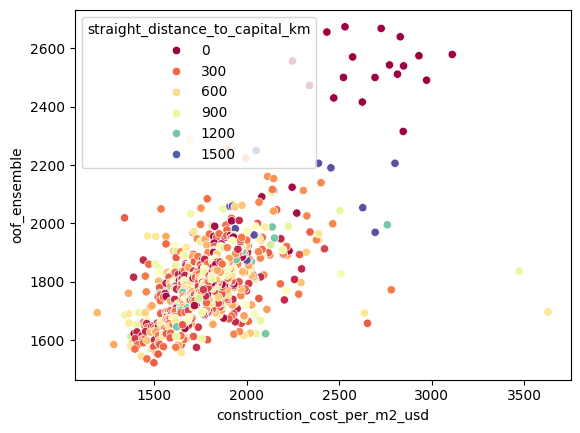

In [60]:
plt.figure()
sns.scatterplot(data=df_res_jp,x="construction_cost_per_m2_usd",y="oof_ensemble",hue="straight_distance_to_capital_km",palette="Spectral")

In [89]:
df_shimane=df_res_jp.loc[df_res_jp["geolocation_name"].str.contains("Shimane")]
df_shimane.sort_values("quarter_label",inplace=True)
df_shimane

,data_id,geolocation_name,quarter_label,country,year,deflated_gdp_usd,us_cpi,developed_country,landlocked,region_economic_classification,access_to_airport,access_to_port,access_to_highway,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,sentinel2_tiff_file_name,viirs_tiff_file_name,construction_cost_per_m2_usd,B1_pct0,B1_pct10,B1_pct20,B1_pct30,B1_pct40,B1_pct50,B1_pct60,B1_pct70,B1_pct80,B1_pct90,B1_pct100,B1_mean,B1_std,B2_pct0,B2_pct10,B2_pct20,B2_pct30,B2_pct40,B2_pct50,B2_pct60,B2_pct70,B2_pct80,B2_pct90,B2_pct100,B2_mean,B2_std,B3_pct0,B3_pct10,B3_pct20,B3_pct30,B3_pct40,B3_pct50,B3_pct60,B3_pct70,B3_pct80,B3_pct90,B3_pct100,B3_mean,B3_std,B4_pct0,B4_pct10,B4_pct20,B4_pct30,B4_pct40,B4_pct50,B4_pct60,B4_pct70,B4_pct80,B4_pct90,B4_pct100,B4_mean,B4_std,B5_pct0,B5_pct10,B5_pct20,B5_pct30,B5_pct40,B5_pct50,B5_pct60,B5_pct70,B5_pct80,B5_pct90,B5_pct100,B5_mean,B5_std,B6_pct0,B6_pct10,B6_pct20,B6_pct30,B6_pct40,B6_pct50,B6_pct60,B6_pct70,B6_pct80,B6_pct90,B6_pct100,B6_mean,...,BSI_pct100,BSI_mean,BSI_std,NBSI_pct0,NBSI_pct10,NBSI_pct20,NBSI_pct30,NBSI_pct40,NBSI_pct50,NBSI_pct60,NBSI_pct70,NBSI_pct80,NBSI_pct90,NBSI_pct100,NBSI_mean,NBSI_std,NDWI_pct0,NDWI_pct10,NDWI_pct20,NDWI_pct30,NDWI_pct40,NDWI_pct50,NDWI_pct60,NDWI_pct70,NDWI_pct80,NDWI_pct90,NDWI_pct100,NDWI_mean,NDWI_std,MNDWI_pct0,MNDWI_pct10,MNDWI_pct20,MNDWI_pct30,MNDWI_pct40,MNDWI_pct50,MNDWI_pct60,MNDWI_pct70,MNDWI_pct80,MNDWI_pct90,MNDWI_pct100,MNDWI_mean,MNDWI_std,Clay_pct0,Clay_pct10,Clay_pct20,Clay_pct30,Clay_pct40,Clay_pct50,Clay_pct60,Clay_pct70,Clay_pct80,Clay_pct90,Clay_pct100,Clay_mean,Clay_std,IronOxide_pct0,IronOxide_pct10,IronOxide_pct20,IronOxide_pct30,IronOxide_pct40,IronOxide_pct50,IronOxide_pct60,IronOxide_pct70,IronOxide_pct80,IronOxide_pct90,IronOxide_pct100,IronOxide_mean,IronOxide_std,Carbonate_pct0,Carbonate_pct10,Carbonate_pct20,Carbonate_pct30,Carbonate_pct40,Carbonate_pct50,Carbonate_pct60,Carbonate_pct70,Carbonate_pct80,Carbonate_pct90,Carbonate_pct100,Carbonate_mean,Carbonate_std,avg_rad_pct0,avg_rad_pct10,avg_rad_pct20,avg_rad_pct30,avg_rad_pct40,avg_rad_pct50,avg_rad_pct60,avg_rad_pct70,avg_rad_pct80,avg_rad_pct90,avg_rad_pct100,avg_rad_mean,avg_rad_std,oof_lgb,oof_cb,oof_ensemble,diff,diff_abs,quarter
247,L68NT,32000 Shimane,2019-Q1,Japan,2019,4.070265e+12,115.978119,Yes,No,High income,Yes,Yes,Yes,Yes,650.0,Moderate,Yes,Moderate,Low,Cfa,sentinel_2_32000_shimane_2019-Q1.tif,viirs_32000_shimane_2019-Q1.tif,1714.530335,88.0,265.0,329.0,389.0,451.0,520.0,607.0,729.0,950.0,1570.0,11021.0,802.489926,911.871041,77.0,257.0,317.0,372.0,432.0,500.5,588.0,712.0,908.0,1446.0,11191.0,763.543911,862.807526,122.0,347.0,402.0,454.5,514.0,586.0,681.0,816.0,995.0,1463.0,10835.0,830.988035,800.646723,82.0,276.0,334.0,387.0,448.0,523.5,634.0,796.0,1001.0,1419.0,10695.0,777.780676,793.584721,61.0,541.5,615.0,675.0,740.0,819.5,931.0,1092.5,1308.0,1700.0,11063.0,1058.453031,786.237776,32.0,1193.0,1334.0,1434.0,1524.0,1616.0,1716.0,1836.0,2004.5,2357.0,10623.0,1739.771211,...,0.308176,-0.164311,0.112677,-0.810056,-0.390981,-0.332329,-0.290442,-0.254929,-0.221411,-0.187889,-0.153245,-0.115227,-0.065831,0.430632,-0.224469,0.125071,-0.830963,-0.695817,-0.653939,-0.616659,-0.578384,-0.535253,-0.482495,-0.417681,-0.328729,-0.181934,0.740701,-0.479990,0.214543,-0.674902,-0.506928,-0.468192,-0.433263,-0.398420,-0.361181,-0.318330,-0.260520,-0.164539,-0.003082,0.807882,-0.300821,0.219454,0.526786,1.255109,1.423800,1.515568,1.579716,1.635659,1.692427,1.755054,1.832049,1.940051,2.796482,1.621996,0.253761,0.191718,0.822072,0.898214,0.954060,1.003956,1.053533,1.105128,1.164773,1.240122,1.349810,2.586207,1.071838,0.205343,0.126186,0.438430,0.502445,0.551110,0.594314,0.636771,0.682635,0.734230,0.794770,0.880415,2.564171,0.651740,0.172581,0.05,0.19,0.21,0.23,0.25,0.28,0.33,0.40,0.54,0.94,41.970001,0.589339,1.362154,2007.505642,1937.344382,1972.425012,257.894677,257.8946

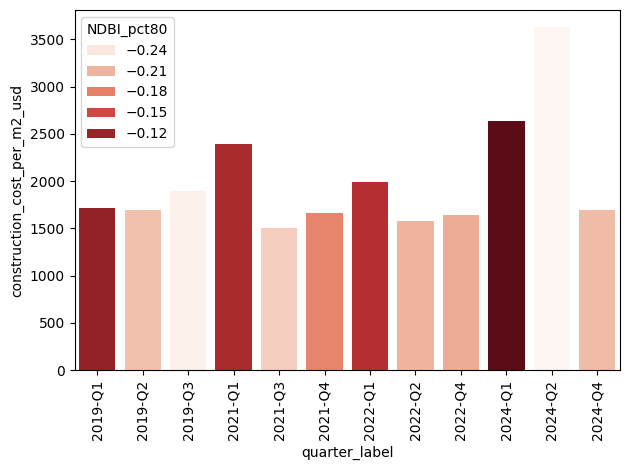

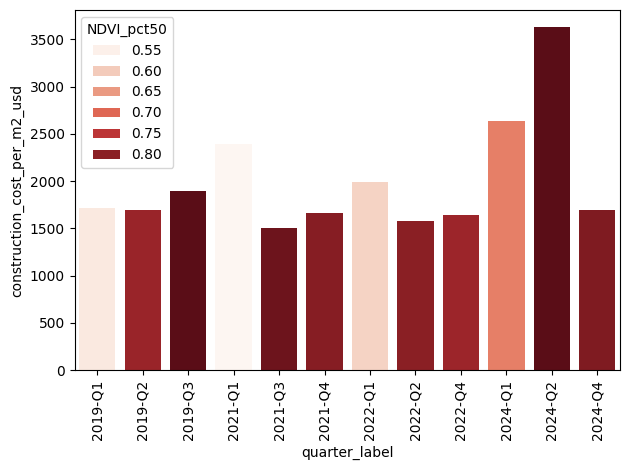

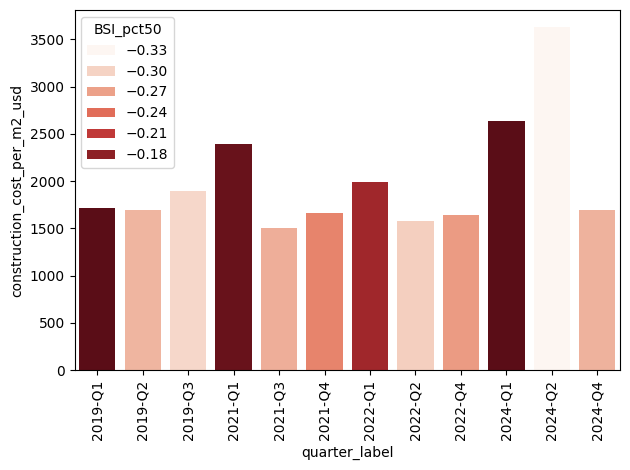

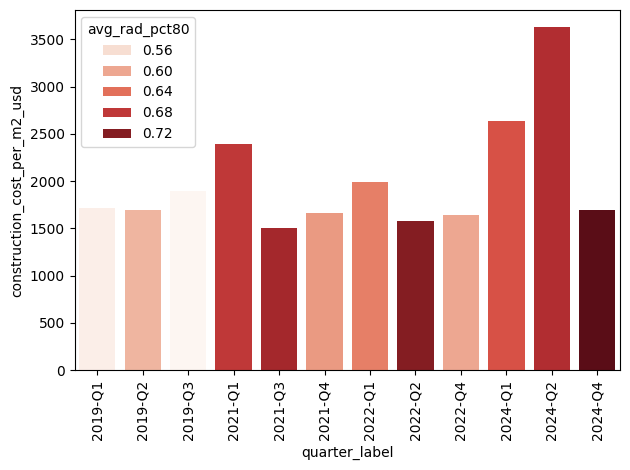

In [91]:
plt.figure()
sns.barplot(data=df_shimane,x="quarter_label",y="construction_cost_per_m2_usd",hue="NDBI_pct80",palette="Reds")
plt.xticks(rotation=90)
plt.tight_layout()
plt.figure()
sns.barplot(data=df_shimane,x="quarter_label",y="construction_cost_per_m2_usd",hue="NDVI_pct50",palette="Reds")
plt.xticks(rotation=90)
plt.tight_layout()
plt.figure()
sns.barplot(data=df_shimane,x="quarter_label",y="construction_cost_per_m2_usd",hue="BSI_pct50",palette="Reds")
plt.xticks(rotation=90)
plt.tight_layout()
plt.figure()
sns.barplot(data=df_shimane,x="quarter_label",y="construction_cost_per_m2_usd",hue="avg_rad_pct80",palette="Reds")
plt.xticks(rotation=90)
plt.tight_layout()



/tmp/ipykernel_21026/3705925712.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_res_jp["quarter"]=df_res_jp["quarter_label"].apply(lambda x:x.split("-")[1])


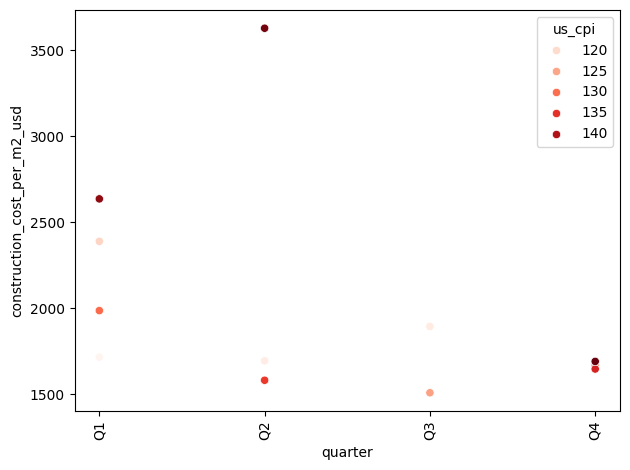

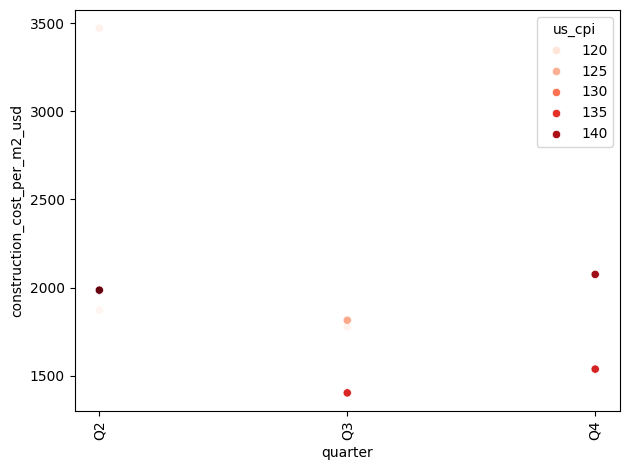

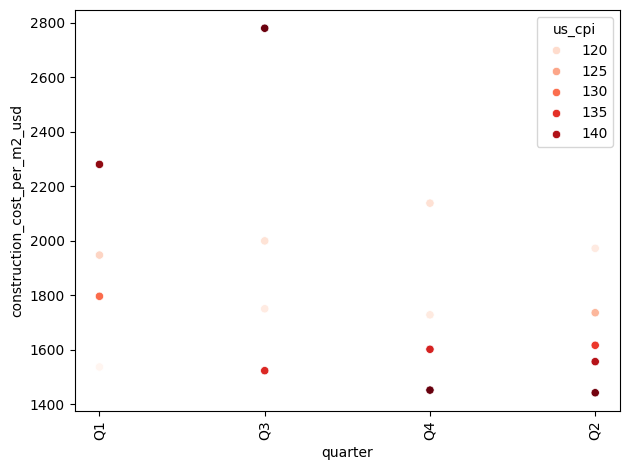

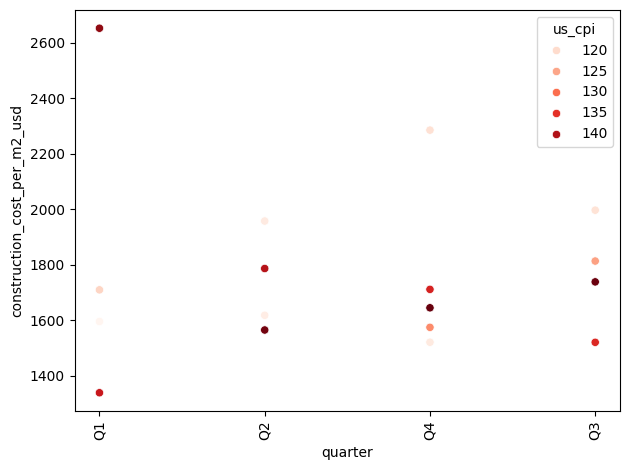

In [87]:
for name in ["Shimane","Kumamoto","Shiga","Toyama"]:
    df_shimane=df_res_jp.loc[df_res_jp["geolocation_name"].str.contains(name)]
    df_shimane.sort_values("quarter_label",inplace=True)


    plt.figure()
    sns.scatterplot(data=df_shimane,x="quarter",y="construction_cost_per_m2_usd",hue="us_cpi",palette="Reds")
    plt.xticks(rotation=90)
    plt.tight_layout()
